### Processing Dataset

In [ ]:
import numpy as np
import pandas as pd

page_ind = pd.read_csv('data-pages-202401.csv')
page_ind = page_ind.fillna({'domain_code': 'NA', 'page_title': 'NA'})

pageview = np.zeros(len(page_ind))
for day in range(1, 32):
    print('Day:', day)
    data = pd.read_csv(f'data-202401{day:02d}.csv.gz', compression='gzip')
    df_minimal = data[['domain_code', 'page_title']].copy()
    df_minimal['count_views'] = np.sum(data.iloc[:, 2 :].values, axis = 1)
    del data
    df_minimal = df_minimal.fillna({'domain_code': 'NA', 'page_title': 'NA'})
    df_view = pd.merge(page_ind, df_minimal, on=['domain_code', 'page_title'], how='left')
    pageview += df_view['count_views'].values

In [ ]:
df_view['count_views'] = pageview

In [ ]:
df1 = df_view[(df_view['domain_code'] == 'en') | (df_view['domain_code'] == 'en.m')].reset_index(drop=True)
df1

In [ ]:
df1[df1['domain_code'] == 'en']

In [ ]:
df1[df1['page_title'] == 'Anomaly_detection']

### Computing the Mahalanobis Distance

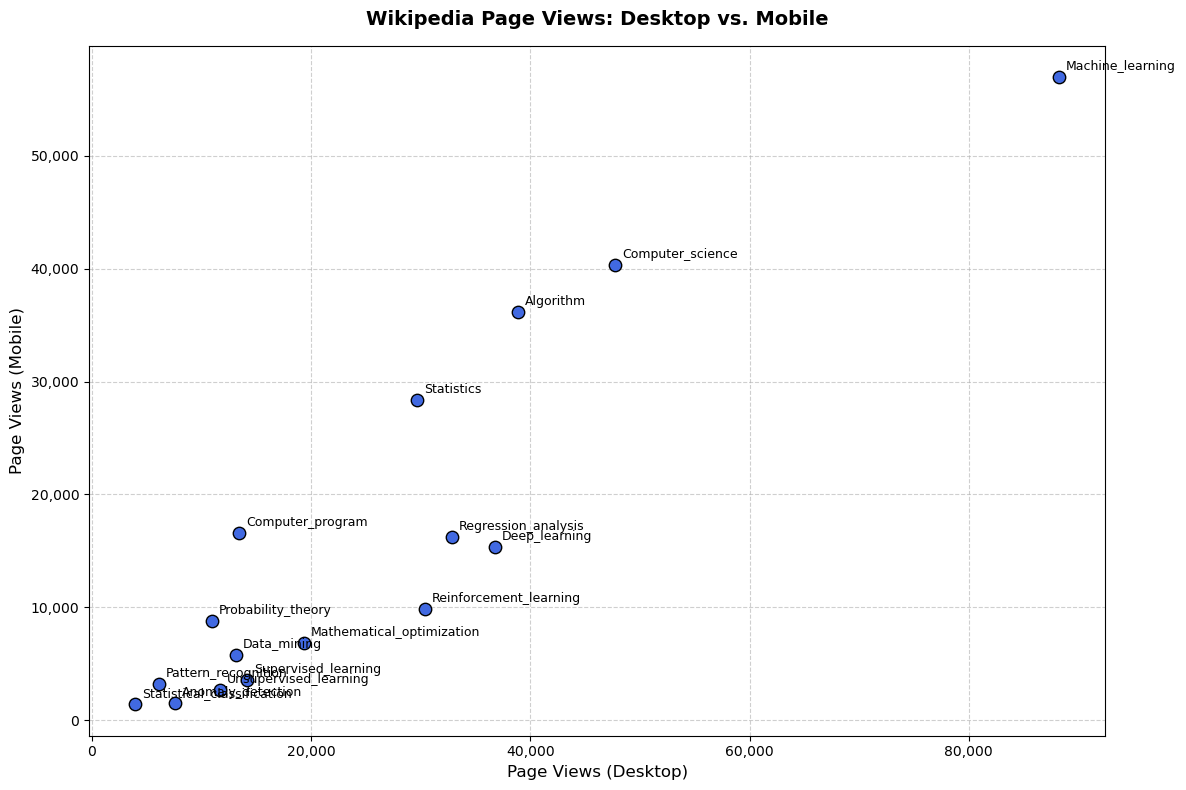

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Prepare the data
data = {
    "Wikipedia page": [
        "Machine_learning", "Artificial_intelligence", "Deep_learning", "Statistics",
        "Mathematical_optimization", "Data_mining", "Supervised_learning", "Unsupervised_learning",
        "Computer_program", "Algorithm", "Reinforcement_learning", "Pattern_recognition",
        "Computer_science", "Probability_theory", "Regression_analysis", "Statistical_classification",
        "Anomaly_detection"
    ],
    "Desktop": [
        88260, 292993, 36741, 29673, 19318, 13168, 14120, 11693,
        13451, 38905, 30393, 6119, 47723, 10913, 32814, 3947, 7540
    ],
    "Mobile": [
        56966, 333552, 15321, 28341, 6819, 5750, 3596, 2702,
        16587, 36203, 9841, 3223, 40321, 8788, 16207, 1403, 1514
    ]
}

df = pd.DataFrame(data)

# Filter out "Artificial_intelligence" and reset the index
df = df[df["Wikipedia page"] != "Artificial_intelligence"].reset_index(drop=True)

# 2. Create the plot
plt.figure(figsize=(12, 8))
plt.scatter(df["Desktop"], df["Mobile"], color="royalblue", edgecolors="black", s=80, zorder=3)

# 3. Add labels to the data points so you know which dot is which
for i, txt in enumerate(df["Wikipedia page"]):
    plt.annotate(
        txt, 
        (df["Desktop"][i], df["Mobile"][i]), 
        textcoords="offset points", 
        xytext=(5, 5), 
        fontsize=9
    )

# 4. Customize the chart aesthetics
plt.title("Wikipedia Page Views: Desktop vs. Mobile", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Page Views (Desktop)", fontsize=12)
plt.ylabel("Page Views (Mobile)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6, zorder=1)

# Format axes with commas for easier reading of large numbers
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()

In [4]:
import numpy as np
from scipy.spatial import distance

df = pd.DataFrame(data)

# 2. Extract the features (Desktop and Mobile)
X = df[["Desktop", "Mobile"]].values

# 3. Compute the Mean vector and Covariance Matrix
mu = np.mean(X, axis=0)
Sigma = np.cov(X, rowvar=False)
inv_Sigma = np.linalg.inv(Sigma)  # Inverse of covariance matrix

# 4. Calculate Mahalanobis distance for each row
mahalanobis_distances = []
for row in X:
    d = distance.mahalanobis(row, mu, inv_Sigma)
    mahalanobis_distances.append(d)

# 5. Add the results back to the DataFrame
df["Mahalanobis_Distance"] = mahalanobis_distances

# Display sorted by highest distance (potential outliers)
df_sorted = df.sort_values(by="Mahalanobis_Distance", ascending=False)
print(df_sorted[["Wikipedia page", "Desktop", "Mobile", "Mahalanobis_Distance"]])

                Wikipedia page  Desktop  Mobile  Mahalanobis_Distance
1      Artificial_intelligence   292993  333552              3.825850
0             Machine_learning    88260   56966              2.839912
8             Computer_program    13451   16587              1.253435
2                Deep_learning    36741   15321              1.252036
10      Reinforcement_learning    30393    9841              1.106745
15  Statistical_classification     3947    1403              0.973998
11         Pattern_recognition     6119    3223              0.908297
13          Probability_theory    10913    8788              0.877307
14         Regression_analysis    32814   16207              0.790066
16           Anomaly_detection     7540    1514              0.672295
3                   Statistics    29673   28341              0.616936
5                  Data_mining    13168    5750              0.488425
7        Unsupervised_learning    11693    2702              0.455318
4    Mathematical_op